# Check whether csv images are imported properly

In [1]:
from qcl_analysis.io import load_qcl_csv

In [2]:
file_path = "/Users/ethanjiang/Documents/Cornell/Research/DIY Incubator/Data/A431_04222026_QCL/2026-04-22_021/stacks/pattern0/lineScan_1600_0invcm.csv"

image = load_qcl_csv(file_path)

print("Shape:", image.shape)
print("Min:", image.min())
print("Max:", image.max())
print("Mean:", image.mean())

Shape: (200, 300)
Min: 0.054339154612244395
Max: 6.8610845076374325
Mean: 2.037347584861144


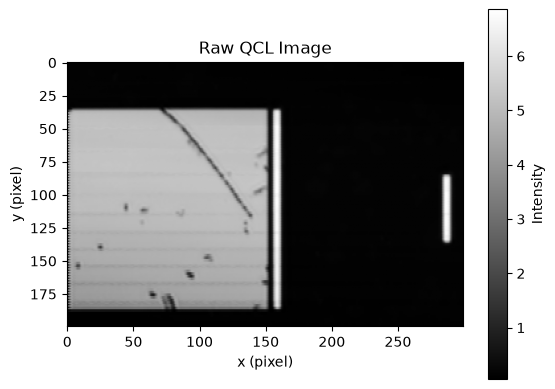

In [3]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.colorbar(label="Intensity")
plt.title("Raw QCL Image")
plt.xlabel("x (pixel)")
plt.ylabel("y (pixel)")
plt.show()

# Turn data from a given folder into metadata table

In [4]:
from qcl_analysis.metadata import index_qcl_dataset

In [5]:
stacks_path = (
    "/Users/ethanjiang/Documents/Cornell/Research/"
    "DIY Incubator/Data/A431_04222026_QCL/"
    "2026-04-22_021/stacks"
)

dataset = index_qcl_dataset(stacks_path)

dataset

,frame,pattern,wavenumber,path
0,0,pattern0,1600,/Users/ethanjiang/Documents/Cornell/Research/D...
1,0,pattern0,1655,/Users/ethanjiang/Documents/Cornell/Research/D...
2,0,pattern0,1750,/Users/ethanjiang/Documents/Cornell/Research/D...
3,1,pattern1,1600,/Users/ethanjiang/Documents/Cornell/Research/D...
4,1,pattern1,1655,/Users/ethanjiang/Documents/Cornell/Research/D...
...,...,...,...,...
516,173,pattern173,1600,/Users/ethanjiang/Documents/Cornell/Research/D...
517,173,pattern173,1655,/Users/ethanjiang/Documents/Cornell/Research/D...
518,173,pattern173,1750,/Users/ethanjiang/Documents/Cornell/Research/D...
519,174,pattern174,1600,/Users/ethanjiang/Documents/Cornell/Research/D...


In [6]:
dataset.shape

(521, 4)

In [7]:
dataset["frame"].unique()

array([  0,   1,   2,   3,   4,   5,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174])

In [8]:
dataset["wavenumber"].unique()

array([1600, 1655, 1750])

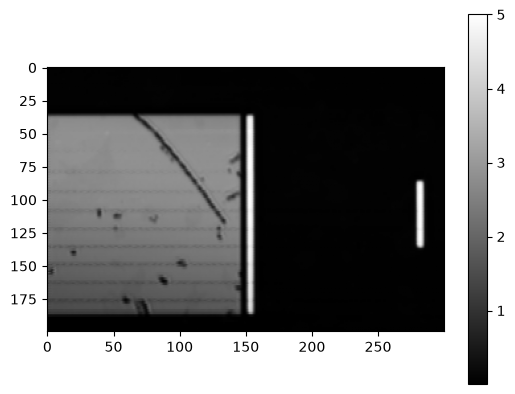

In [9]:
row = dataset[
    (dataset["frame"] == 100)
    & (dataset["wavenumber"] == 1655)
].iloc[0]

image = load_qcl_csv(row["path"])

plt.imshow(image, cmap="gray")
plt.colorbar()
plt.show()

# Check quality of the dataset

In [ ]:
from qcl_analysis.qc import validate_dataset_index
from qcl_analysis.qc import find_incomplete_frames
from qcl_analysis.qc import validate_image_files

In [11]:
incomplete = find_incomplete_frames(
    dataset,
    expected_wavenumbers={1600, 1655, 1750},
)

incomplete

{174: [1750]}